# Preprocessing and Quantization Benchmark

We'll try additional approaches:

- **Preprocessing**: Identity, L2, PCA at several
  target dims, Random Rotation.
- **Quantization**: SQ (8-bit / 4-bit / fp16), PQ,
  Residual Quantization, Local Search Quantization, Product-Residual,
  Product-LSQ.


## 1. Setup

In [5]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

sys.path.insert(0, str(ROOT.parent))

from sources import NumpyFileSource

EMBEDS_PATH = ROOT / "embeds.npy"

FALLBACK_N = 20_000
FALLBACK_DIM = 768
FALLBACK_HIDDEN = 50

N_QUERIES = 200
TOPK = 10
SEED = 0

print(f"faiss version: {faiss.__version__}")


faiss version: 1.14.3


## 2. Corpus + queries + ground truth

In [ ]:
def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)

src = NumpyFileSource(EMBEDS_PATH)
raw = np.asarray(src._vectors[:], dtype=np.float32)
print(f"real embeddings   : {EMBEDS_PATH}  N={raw.shape[0]:,}  dim={raw.shape[1]}")


N, DIM = raw.shape
# corpus = l2_normalize(raw)
corpus = raw

rng = np.random.default_rng(123)
qry_idx = rng.choice(N, size=N_QUERIES, replace=False)
queries = corpus[qry_idx].copy()


gt_index = faiss.IndexFlatIP(DIM)
gt_index.add(corpus)
_, gt = gt_index.search(queries, TOPK)
print(f"ground truth ready: {gt.shape}")


real embeddings   : /Users/tomatocoder/Desktop/local-wiki-rag/data/embeds.npy  N=500,000  dim=256
ground truth ready: (200, 10)


## 3. Reusable measurement functions

We want three numbers for every method under test:

- **recall@10** — did the shortlist recover the true neighbours?
- **memory / vector** — encoded bytes per vector (the important cost)
- **build/encode time** — one-shot cost of preparing the corpus

In [7]:
def recall_from_labels(labels, gt, k=TOPK):
    hits = sum(len(set(labels[i].tolist()) & set(gt[i].tolist()))
               for i in range(len(labels)))
    return hits / (len(labels) * k)


def bench_faiss_index(idx, queries, gt, k=TOPK, n_repeats=1):
    _ = idx.search(queries[:1], k)  # warmup
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        _, labels = idx.search(queries, k)
    lat_ms = (time.perf_counter() - t0) / (n_repeats * len(queries)) * 1000
    return recall_from_labels(labels, gt, k), lat_ms


def encode_decode_mse(idx, sample):
    """Reconstruction MSE per vector. Works for any FAISS index whose
    ``sa_encode`` + ``sa_decode`` are wired up."""
    codes = idx.sa_encode(sample)
    recon = idx.sa_decode(codes)
    diff = sample - recon
    return float((diff * diff).mean() * sample.shape[1]), codes.shape[1]


all_results = []


## Preprocessing

Compare identity / PCA at several target dims / random rotation

In [24]:
prep_rows = []

# --- Identity baseline ---
prep_rows.append({
    "method": "identity",
    "config": f"dim={DIM}",
    "target_dim": DIM,
    "recall@10": 1.0,
    "latency_ms": 0.0,
    "memory_bytes_per_vec": DIM * 4,
})
print(f"identity baseline (dim={DIM})  memory={DIM*4} B/vec")


# --- PCA at target dims ---
for target in [64, 128, 192, 256, 384, 512]:
    if target >= DIM:
        continue
    pca = faiss.PCAMatrix(DIM, target, 0, True)
    pca.train(corpus)
    c_pca = pca.apply(corpus)
    q_pca = pca.apply(queries)
    # Re-normalize for IP semantics (PCA doesn't preserve norm).
    c_pca = l2_normalize(c_pca).astype(np.float32)
    q_pca = l2_normalize(q_pca).astype(np.float32)

    idx = faiss.IndexFlatIP(target)
    idx.add(c_pca)
    r, lat = bench_faiss_index(idx, q_pca, gt)
    prep_rows.append({
        "method": "pca",
        "config": f"dim={target}",
        "target_dim": target,
        "recall@10": r,
        "latency_ms": lat,
        "memory_bytes_per_vec": target * 4,
    })
    print(f"  pca -> dim={target:>3}  recall@10={r:.3f}  memory={target*4} B/vec")


# Random rotation (norm-preserving)
rrot = faiss.RandomRotationMatrix(DIM, DIM)
rrot.init(SEED)
c_rot = rrot.apply(corpus)
q_rot = rrot.apply(queries)
c_rot = l2_normalize(c_rot).astype(np.float32)
q_rot = l2_normalize(q_rot).astype(np.float32)
idx = faiss.IndexFlatIP(DIM)
idx.add(c_rot)
r, lat = bench_faiss_index(idx, q_rot, gt)
prep_rows.append({
    "method": "random_rotation",
    "config": f"dim={DIM}",
    "target_dim": DIM,
    "recall@10": r,
    "latency_ms": lat,
    "memory_bytes_per_vec": DIM * 4,
})
print(f"random_rotation  recall@10={r:.3f}  (should be ≈ 1.0 — sanity)")

prep_df = pd.DataFrame(prep_rows)
prep_df


identity baseline (dim=256)  memory=1024 B/vec
  pca -> dim= 64  recall@10=0.571  memory=256 B/vec
  pca -> dim=128  recall@10=0.772  memory=512 B/vec
  pca -> dim=192  recall@10=0.868  memory=768 B/vec
random_rotation  recall@10=0.999  (should be ≈ 1.0 — sanity)


,method,config,target_dim,recall@10,latency_ms,memory_bytes_per_vec
0,identity,dim=256,256,1.0000,0.000000,1024
1,pca,dim=64,64,0.5710,0.731419,256
2,pca,dim=128,128,0.7725,1.643412,512
3,pca,dim=192,192,0.8675,2.601120,768
4,random_rotation,dim=256,256,0.9985,3.617840,1024


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for method, sub in prep_df.groupby("method"):
    sub = sub.sort_values("target_dim")
    ax.plot(sub["memory_bytes_per_vec"], sub["recall@10"],
            marker="o", linewidth=2, markersize=9, label=method)

ax.set_xlabel("memory per vector (bytes)")
ax.set_ylabel("recall@10")
ax.set_title("Preprocessing — recall vs memory")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


As we can see PCA pca is ineffective at preserving recall

## Quantization

Six quantizers, each hitting a different point on the recall /
memory / time surface

| Method | FAISS class | Codebook shape |
| --- | --- | --- |
| SQ 8-bit | `IndexScalarQuantizer(QT_8bit)`  | 1 byte per dim |
| SQ 4-bit | `IndexScalarQuantizer(QT_4bit)`  | 0.5 byte per dim |
| SQ fp16  | `IndexScalarQuantizer(QT_fp16)`  | 2 bytes per dim |
| PQ       | `IndexPQ(M, nbits)`              | M × nbits bits per vec |
| RQ       | `IndexResidualQuantizer(M, nbits)` | M × nbits bits per vec |
| LSQ      | `IndexLocalSearchQuantizer(M, nbits)` | M × nbits bits per vec |
| PRQ      | `IndexProductResidualQuantizer(nsplits, Msub, nbits)` | nsplits × Msub × nbits bits |
| PLSQ     | `IndexProductLocalSearchQuantizer(nsplits, Msub, nbits)` | same shape |


In [12]:
SAMPLE_MSE = min(8192, N)
sample_for_mse = corpus[:SAMPLE_MSE]


def evaluate_faiss_encoder(name, config, idx, corpus, queries, gt, sample):
    t0 = time.perf_counter()
    idx.train(corpus) if not idx.is_trained else None
    idx.add(corpus)
    build_s = time.perf_counter() - t0

    recall, lat = bench_faiss_index(idx, queries, gt)
    try:
        mse, code_bytes = encode_decode_mse(idx, sample)
    except Exception:
        mse, code_bytes = float("nan"), np.nan
    return {
        "method": name, "config": config,
        "recall@10": recall, "latency_ms": lat,
        "build_s": round(build_s, 3),
        "mse": mse,
        "memory_bytes_per_vec": int(code_bytes) if not np.isnan(code_bytes) else np.nan,
    }


quant_rows = []


### Scalar quantization

In [13]:
# QT_fp16 doesn't need training but the API accepts it.
for label, qtype in [("sq_fp16", faiss.ScalarQuantizer.QT_fp16),
                     ("sq_8bit", faiss.ScalarQuantizer.QT_8bit),
                     ("sq_4bit", faiss.ScalarQuantizer.QT_4bit)]:
    idx = faiss.IndexScalarQuantizer(DIM, qtype, faiss.METRIC_INNER_PRODUCT)
    row = evaluate_faiss_encoder(label, label, idx, corpus, queries, gt, sample_for_mse)
    quant_rows.append(row)
    print(f"  {label:<10}  recall={row['recall@10']:.3f}  "
          f"mem={row['memory_bytes_per_vec']} B  mse={row['mse']:.4e}  "
          f"lat={row['latency_ms']:.3f} ms")


  sq_fp16     recall=0.493  mem=512 B  mse=2.5649e-08  lat=1.916 ms
  sq_8bit     recall=0.255  mem=256 B  mse=3.4562e-05  lat=3.094 ms
  sq_4bit     recall=0.068  mem=128 B  mse=1.1768e-02  lat=21.787 ms


### Product Quantization

`IndexPQ(D, M, nbits)` splits the vector into `M` subvectors and
codes each with `nbits`. Memory = `M × nbits / 8` bytes/vec.


In [14]:
for M, nbits in [(64, 8), (16, 4), (256, 4), (256, 8)]:
    if DIM % M != 0:
        continue  # PQ requires DIM divisible by M
    idx = faiss.IndexPQ(DIM, M, nbits, faiss.METRIC_INNER_PRODUCT)
    row = evaluate_faiss_encoder(f"pq_{M}x{nbits}", f"M={M}, nbits={nbits}",
                                  idx, corpus, queries, gt, sample_for_mse)
    quant_rows.append(row)
    print(f"  pq_{M}x{nbits:<3}  recall={row['recall@10']:.3f}  "
          f"mem={row['memory_bytes_per_vec']} B  mse={row['mse']:.4e}  "
          f"lat={row['latency_ms']:.3f} ms")


  pq_64x8    recall=0.064  mem=64 B  mse=3.6325e-03  lat=2.524 ms
  pq_16x4    recall=0.001  mem=8 B  mse=2.2337e-02  lat=1.099 ms
  pq_256x4    recall=0.052  mem=128 B  mse=3.5788e-03  lat=22.649 ms
  pq_256x8    recall=0.728  mem=256 B  mse=7.3477e-05  lat=18.780 ms


### Residual Quantization

In [15]:
for M, nbits in [(4, 8), (8, 8), (16, 8), (8, 4)]:
    idx = faiss.IndexResidualQuantizer(DIM, M, nbits, faiss.METRIC_INNER_PRODUCT)
    row = evaluate_faiss_encoder(f"rq_{M}x{nbits}", f"M={M}, nbits={nbits}",
                                  idx, corpus, queries, gt, sample_for_mse)
    quant_rows.append(row)
    print(f"  rq_{M}x{nbits:<3}  recall={row['recall@10']:.3f}  "
          f"mem={row['memory_bytes_per_vec']} B  mse={row['mse']:.4e}  "
          f"lat={row['latency_ms']:.3f} ms")


  rq_4x8    recall=0.013  mem=4 B  mse=7.1097e-03  lat=17.849 ms
  rq_8x8    recall=0.025  mem=8 B  mse=5.1548e-03  lat=26.411 ms
  rq_16x8    recall=0.056  mem=16 B  mse=3.4317e-03  lat=88.759 ms
  rq_8x4    recall=0.007  mem=4 B  mse=9.2683e-03  lat=45.490 ms


### Local Search Quantization

In [17]:
for M, nbits in [(4, 8), (8, 8)]:
    idx = faiss.IndexLocalSearchQuantizer(DIM, M, nbits, faiss.METRIC_INNER_PRODUCT)
    row = evaluate_faiss_encoder(f"lsq_{M}x{nbits}", f"M={M}, nbits={nbits}",
                                  idx, corpus, queries, gt, sample_for_mse)
    quant_rows.append(row)
    print(f"  lsq_{M}x{nbits:<3}  recall={row['recall@10']:.3f}  "
          f"mem={row['memory_bytes_per_vec']} B  mse={row['mse']:.4e}  "
          f"lat={row['latency_ms']:.3f} ms")


KeyboardInterrupt: 

### Product Residual + Product LSQ

Both split the vector into `nsplits` blocks and run RQ / LSQ on each
independently. More total codebooks, sometimes better recall at the
same memory.


In [ ]:
for nsplits, Msub, nbits in [(2, 4, 8), (4, 2, 8)]:
    for label, cls in [("prq", faiss.IndexProductResidualQuantizer),
                       ("plsq", faiss.IndexProductLocalSearchQuantizer)]:
        idx = cls(DIM, nsplits, Msub, nbits, faiss.METRIC_INNER_PRODUCT)
        cfg = f"nsplits={nsplits}, Msub={Msub}, nbits={nbits}"
        try:
            row = evaluate_faiss_encoder(f"{label}_{nsplits}x{Msub}x{nbits}",
                                          cfg, idx, corpus, queries, gt, sample_for_mse)
            quant_rows.append(row)
            print(f"  {label}_{nsplits}x{Msub}x{nbits:<3}  recall={row['recall@10']:.3f}  "
                  f"mem={row['memory_bytes_per_vec']} B  mse={row['mse']:.4e}  "
                  f"lat={row['latency_ms']:.3f} ms")
        except Exception as e:
            print(f"  {label}_{nsplits}x{Msub}x{nbits}  FAILED: {e}")


  prq_2x4x8    recall=0.021  mem=8 B  mse=6.5071e-03  lat=29.554 ms
  plsq_2x4x8    recall=0.020  mem=8 B  mse=6.7814e-03  lat=32.347 ms
  prq_4x2x8    recall=0.010  mem=8 B  mse=8.3229e-03  lat=29.525 ms
  plsq_4x2x8    recall=0.013  mem=8 B  mse=8.2881e-03  lat=27.389 ms


OSError: Cannot save file into a non-existent directory: '/Users/tomatocoder/Desktop/local-wiki-rag/data/experiments'

In [ ]:
quant_df = pd.DataFrame(quant_rows)
quant_df.to_csv(Path.cwd().parent / "indexing" / "experiments" / "quantization.csv", index=False)
quant_df.round(4)

,method,config,recall@10,latency_ms,build_s,mse,memory_bytes_per_vec
0,sq_fp16,sq_fp16,0.4930,1.9159,0.061,0.0000,512
1,sq_8bit,sq_8bit,0.2545,3.0938,0.084,0.0000,256
2,sq_4bit,sq_4bit,0.0680,21.7866,0.101,0.0118,128
3,pq_64x8,"M=64, nbits=8",0.0640,2.5237,7.390,0.0036,64
4,pq_16x4,"M=16, nbits=4",0.0005,1.0990,0.590,0.0223,8
5,pq_256x4,"M=256, nbits=4",0.0520,22.6487,2.944,0.0036,128
6,pq_256x8,"M=256, nbits=8",0.7280,18.7804,36.648,0.0001,256
7,rq_4x8,"M=4, nbits=8",0.0125,17.8491,29.903,0.0071,4
8,rq_8x8,"M=8, nbits=8",0.0250,26.4112,42.178,0.0052,8
9,rq_16x8,"M=16, nbits=8",0.0560,88.7586,170.611,0.0034,16


## The three trade-off plots

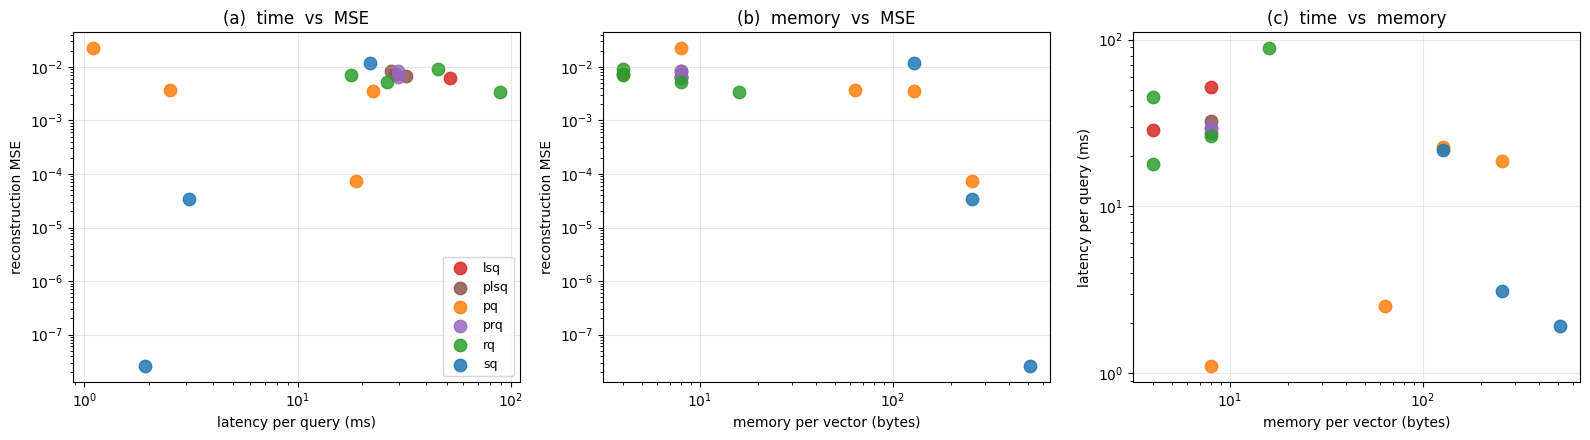

In [20]:
def method_family(name):
    for prefix in ["sq", "pq", "rq", "lsq", "prq", "plsq"]:
        if name.startswith(prefix + "_") or name == prefix:
            return prefix
    return "other"


quant_df["family"] = quant_df["method"].map(method_family)

family_colors = {
    "sq":   "tab:blue",
    "pq":   "tab:orange",
    "rq":   "tab:green",
    "lsq":  "tab:red",
    "prq":  "tab:purple",
    "plsq": "tab:brown",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) time vs mse
ax = axes[0]
for family, sub in quant_df.groupby("family"):
    ax.scatter(sub["latency_ms"], sub["mse"],
               s=80, color=family_colors.get(family, "grey"),
               label=family, alpha=0.85)
ax.set_xlabel("latency per query (ms)")
ax.set_ylabel("reconstruction MSE")
ax.set_title("(a)  time  vs  MSE")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

# (2) memory vs mse
ax = axes[1]
for family, sub in quant_df.groupby("family"):
    ax.scatter(sub["memory_bytes_per_vec"], sub["mse"],
               s=80, color=family_colors.get(family, "grey"),
               label=family, alpha=0.85)
ax.set_xlabel("memory per vector (bytes)")
ax.set_ylabel("reconstruction MSE")
ax.set_title("(b)  memory  vs  MSE")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.3)

# (3) time vs memory
ax = axes[2]
for family, sub in quant_df.groupby("family"):
    ax.scatter(sub["memory_bytes_per_vec"], sub["latency_ms"],
               s=80, color=family_colors.get(family, "grey"),
               label=family, alpha=0.85)
ax.set_xlabel("memory per vector (bytes)")
ax.set_ylabel("latency per query (ms)")
ax.set_title("(c)  time  vs  memory")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Recall vs memory (headline plot)

The plot most people actually care about — how much recall do you keep
per byte you spend?


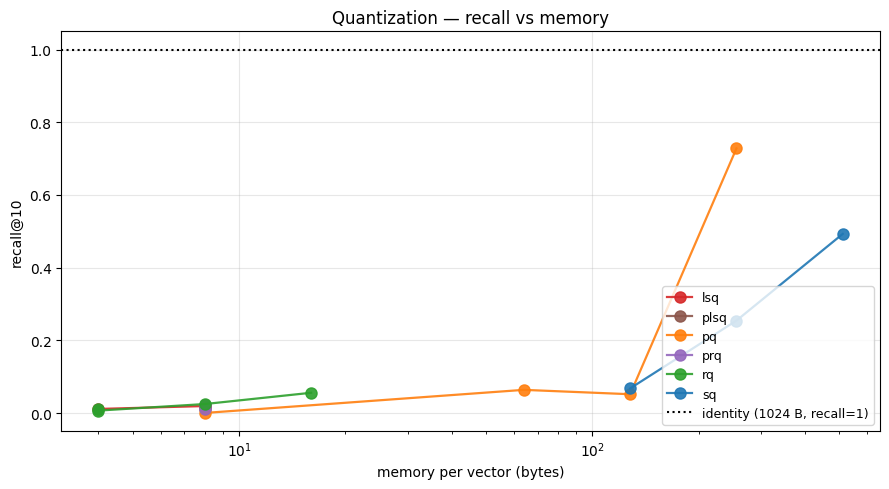

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
for family, sub in quant_df.groupby("family"):
    sub = sub.sort_values("memory_bytes_per_vec")
    ax.plot(sub["memory_bytes_per_vec"], sub["recall@10"],
            marker="o", linewidth=1.6, markersize=8,
            color=family_colors.get(family, "grey"),
            label=family, alpha=0.9)

# Add identity baseline as a horizontal reference.
identity_mem = prep_df[prep_df["method"] == "identity"]["memory_bytes_per_vec"].iloc[0]
ax.axhline(1.0, color="black", linestyle=":", label=f"identity ({identity_mem} B, recall=1)")

ax.set_xlabel("memory per vector (bytes)")
ax.set_ylabel("recall@10")
ax.set_title("Quantization — recall vs memory")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()


## Summary table

In [26]:
both = pd.concat([
    prep_df.assign(family=prep_df["method"]),
    quant_df.drop(columns=["family"]).assign(family=quant_df["method"].map(method_family)),
], ignore_index=True)

both["compression"] = (DIM * 4) / both["memory_bytes_per_vec"]

summary = (
    both[["method", "config", "recall@10", "memory_bytes_per_vec",
          "compression"]]
    .round(4)
    .sort_values("memory_bytes_per_vec")
    .reset_index(drop=True)
)
summary


,method,config,recall@10,memory_bytes_per_vec,compression
0,lsq_4x8,"M=4, nbits=8",0.0115,4,256.0000
1,rq_8x4,"M=8, nbits=4",0.0070,4,256.0000
2,rq_4x8,"M=4, nbits=8",0.0125,4,256.0000
3,plsq_4x2x8,"nsplits=4, Msub=2, nbits=8",0.0125,8,128.0000
4,plsq_2x4x8,"nsplits=2, Msub=4, nbits=8",0.0200,8,128.0000
5,prq_2x4x8,"nsplits=2, Msub=4, nbits=8",0.0215,8,128.0000
6,lsq_8x8,"M=8, nbits=8",0.0195,8,128.0000
7,rq_8x8,"M=8, nbits=8",0.0250,8,128.0000
8,pq_16x4,"M=16, nbits=4",0.0005,8,128.0000
9,prq_4x2x8,"nsplits=4, Msub=2, nbits=8",0.0100,8,128.0000


The most promising methods are PQ and SQ